In [151]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import defaultdict
from xgboost import XGBRegressor
import tensorflow
from tensorflow.keras import models, layers
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt 
from tensorflow.keras.optimizers import Adam
from pathlib import Path

from sklearn.metrics import mean_squared_error
import numpy as np
import math

import json
import os

Supplementary Data Processing

In [2]:
def processed_holidays_events():
    """
    Returns an embedded dictionary with has_holiday[data][locale] returning True or False

    Returns
    -------
    has_holiday: dict
        The dictionary returning whether theres a holiday on that given day
    """

    holidays_events = pd.read_csv("data/holidays_events.csv")
    holidays_events = holidays_events[holidays_events["transferred"] == False]
    holidays_events = holidays_events.drop(columns=["description"])

    date_grouped_holidays = holidays_events.groupby("date")

    has_holiday = defaultdict(lambda: defaultdict(lambda: False)) #Defaults to {date: {city: False}}
    for date, grouped_table in date_grouped_holidays:
        if "National" in grouped_table["locale"].unique():
            has_holiday[date] = defaultdict(lambda: True)
            continue
        for city in grouped_table["locale_name"].to_list():
            has_holiday[date][city] = True

    return has_holiday

In [3]:
def process_oil_prices():
    """
    Returns a dictionary with date pointing to oil prices.

    Returns
    -------
    oil_prices: dict
        The dictionary with schema {date : oil_price}
    """
    
    oil_prices = pd.read_csv("data/oil.csv").set_index("date")
    return oil_prices.to_dict()['dcoilwtico']

In [4]:
def process_stores_table():
    """
    Processes and returns the stores table

    Returns
    -------
    stores: pd.DataFrame 
    """
    
    stores = pd.read_csv("data/stores.csv")

    stores["type"] = stores.apply(
        lambda row: "Other" if row["type"] not in ["D", "C"] else row["type"], axis=1
    )
    
    stores["cluster"] = stores["cluster"].astype("category")
    stores["type"] = stores["type"].astype("category")

    return stores


Time Series Data Processing

In [112]:
def process_lstm_data(data, grouping_category = 1):
    """
    Processes store price data and groups by store_nbr, family

    Paramters
    ---------
    data: pd.DataFrame
        The dataframe containing the time series data
    
    Returns
    -------
    key_to_df : dict[str: pd.DataFrame]
        dictionary with (store_nbr, family) pointing to the grouped dataframe
    """
    
    if grouping_category == 1:
        grouped_data =  data.groupby(["store_nbr", "family"])
    elif grouping_category == 2:
        grouped_data = data.groupby("store_nbr")
    elif grouping_category == 3:
        grouped_data = data.groupby("family")
        
    key_to_df = {}
    key_to_scale_factors = {}
    for key, grouped_df in grouped_data:
        grouped_df = grouped_df[["date", "sales", "onpromotion", "has_holiday", "oil_price"]]

        if grouping_category != 1:

            grouped_df = (
                grouped_df.groupby("date")
                        .agg({
                            "sales": "mean",
                            "onpromotion": "mean",
                            "has_holiday": "first",
                            "oil_price": "first",
                        })
            )

            grouped_df = grouped_df.rename_axis("date_index")
            grouped_df["date"] = grouped_df.index
        
        scale_factor = max(grouped_df["sales"].max(), 1)
        grouped_df["sales"] = grouped_df["sales"] / max(grouped_df["sales"].max(), 1)

        key_to_scale_factors[key] = scale_factor
        key_to_df[key] = grouped_df

    return key_to_df, key_to_scale_factors
    

In [6]:
def create_sequences(data_array, seq_len):
    """ 
    Sequentializes an array and returns the sequnces

    Paramters
    ---------
    data_array: np.array
        The array to sequentialize
    seq_len: int
        The length of each sequnce
    
    Returns 
    -------
    X_seq: np.array
        A 2D array containing the sequences from time t-seq_len to time t-1
    y_seq: np.array
        A 1D array containing the value at time t
    """

    X_seq, y_seq = [], []

    for i in range(len(data_array) - seq_len):
        X_seq.append(data_array[i:i+seq_len])
        y_seq.append(data_array[i+seq_len, 0])
    
    return np.array(X_seq), np.array(y_seq).reshape(-1,1)

In [7]:
def preprocess_lstm_data(grouped_data, seq_len):

    # Creating features
    grouped_data["roc"] = grouped_data["sales"].pct_change().fillna(0).replace([np.inf, -np.inf], 0)
    grouped_data['rolling_avg'] = grouped_data['sales'].rolling(window=5, center=False).mean().fillna(0)
    grouped_data['rolling_std'] = grouped_data['sales'].rolling(window=5).std().fillna(0)
    grouped_data["has_holiday"] = grouped_data["has_holiday"].astype(int)

    # Create Sequence values
    grouped_data = grouped_data.sort_values("date")
    features = ["sales", "roc", "rolling_avg", "rolling_std", "has_holiday", "onpromotion", "oil_price"]

    data_array = grouped_data[features].to_numpy()

    X, y = create_sequences(data_array, seq_len)

    return X, y

In [8]:
def train_lstm_model(grouped_data, seq_len):
    """ 
    Initializes a 1D LSTM model trained on grouped (store_nbr, family) data

    Paramters
    ---------
    grouped_data: pd.DataFrame
        The time series data to train on
    seq_len: int
        The window length to train the model on
    
    Returns
    -------
    model: models.Sequential
        The trained LSTM Model
    val_rmse: float
        The Validation Root Mean Squared Error of this model
    index_to_lstm_predictions: dict[int:float]
        The dictionary holding the LSTM prediction value
    """
    
    X, y = preprocess_lstm_data(grouped_data, seq_len)

    # Simple train / test split
    split = int(0.75 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    #Adapting the noramalization layer
    normalizer = layers.Normalization(axis=-1)
    normalizer.adapt(X_train)

    # Initialize the model
    num_features = 7
    hidden_dim = 64

    model = models.Sequential([ 
        layers.Input(shape=(seq_len, num_features)), 
        normalizer,
        layers.LSTM(hidden_dim, dropout=0.2), 
        layers.Dense(1, activation='linear')
    ])

    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.01), 
        loss='mse', 
        metrics=[tensorflow.keras.metrics.RootMeanSquaredError()]
    )   

    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=64,
        verbose=0
    )

    # Validate the model
    train_rmse = history.history['root_mean_squared_error'][-1]
    val_rmse   = history.history['val_root_mean_squared_error'][-1]

    return model, val_rmse, train_rmse


In [102]:
def populate_lstm_predictions(grouped_data, key):
    """
    Runs inference on time series data and populates the X_train dataframe using indices

    Paramters
    ---------
    key: string
        The grouping of the data to populate
    
    Returns
    -------
    index_to_pred: dict[int:float]
        The dictionary representing the model predictions
    """

    try:
        lstm_model = tensorflow.keras.models.load_model(f"my_models/specialist_model_{key}")
    except OSError as e:
        print(f"Model for {key} does not exist")
        return {}
    
    seq_len = lstm_model.input_shape[1]
    num_features = lstm_model.input_shape[2]
    
    X, y = preprocess_lstm_data(grouped_data, seq_len)

    y_pred = lstm_model.predict(X, verbose=0)

    predictions = [np.nan]*seq_len + y_pred.flatten().tolist()

    populated_df = grouped_data.copy()
    populated_df["lstm_forecast"] = predictions
    
    return populated_df["lstm_forecast"].to_dict()

In [10]:
def plot_lstm_predictions(data):
    """Plots the LSTM Forecast for that specific (store_nbr, family) pair."""

    dates = data["date"]
    y_true = data["sales"]
    y_pred = data["lstm_forecast"]

    plt.figure(figsize=(12,6))
    plt.plot(dates, y_true, label='Actual', marker='o')
    plt.plot(dates, y_pred, label='Predicted', marker='x')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title('LSTM Predictions vs Actual Sales')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def train_specialists(train_df, grouping_category=1, override=False):

    key_to_df = process_lstm_data(train_df, grouping_category)
    keys = list(key_to_df.keys())

    for key in keys:
        # Check if model already exists
        model_path = Path(f"my_models/specialist_model_{key}")
        if model_path.exists() and not override:
            continue 
        
        curr_df = key_to_df[key]
            
        del key_to_df[key]
        model, val_rmse, train_rmse = train_lstm_model(curr_df, 20)
        model.save(f"my_models/specialist_model_{key}")

        print(val_rmse, train_rmse)

In [12]:
def process_train_data(data, has_holiday_dict, oil_prices_dict, stores_df):
    
    def has_holiday(date_city_region, has_holiday_dict):
        date, city, region = date_city_region.split("_")
        return has_holiday_dict[date][city] or has_holiday_dict[date][region]
    
    data = pd.merge(data, stores_df, how="left", on="store_nbr")

    data["date_city_region"] = data["date"] + "_" + data["city"] + "_" + data["state"]
    data["has_holiday"] = data["date_city_region"].apply(
        lambda x: has_holiday(x, has_holiday_dict)
    )

    data['weekday'] = pd.to_datetime(data['date']).dt.day_name().astype("category")

    data["oil_price"] = data["date"].map(oil_prices_dict)
    mean_oil_price = data["oil_price"].mean()
    data["oil_price"] = data["oil_price"].fillna(mean_oil_price)
    
    data["family"] = data["family"].astype("category")
    data["store_nbr"] = data["store_nbr"].astype("category")
    data["city"] = data["city"].astype("category")
    data["state"] = data["state"].astype("category")
    data["onpromotion"] = data["onpromotion"].astype("float")
    
    data = data.drop(columns=["date_city_region"])
    
    return data

Specialist LSTM Training

In [197]:
# Fetching train data

train_df = pd.read_csv("data/train.csv")
train_df = train_df[train_df["sales"].notna()]

In [90]:
# Fetching supplamentary data

has_holiday_dict = processed_holidays_events()
oil_prices_dict = process_oil_prices()
stores_df = process_stores_table()

In [198]:
train_df = process_train_data(train_df, has_holiday_dict, oil_prices_dict, stores_df)

In [ ]:
# Fetching scale factors by grouping category

_, scale_factors1 = process_lstm_data(train_df, grouping_category=1)
_, scale_factors2 = process_lstm_data(train_df, grouping_category=2)
_, scale_factors3 = process_lstm_data(train_df, grouping_category=3)

In [ ]:
#train_specialists(train_df, grouping_category=1, override=True)

In [182]:
train_df["temp"] = train_df.apply(
    lambda x: (x["store_nbr"], x["family"]), axis=1
) 

index_to_key = train_df["temp"].to_dict()
train_df = train_df.drop(columns=["temp"])

def scale_df1(index_to_lstm_prediction):
    for index in index_to_lstm_prediction.keys():
        key = index_to_key[int(index)]
        scale_factor = scale_factors1[key]
        index_to_lstm_prediction[index] *= scale_factor
    
    return index_to_lstm_prediction

In [183]:
def populate_category1(override=False, scale=True):
    """Populates train_df with (store_nbr, family) model predictions"""

    index_to_lstm_prediction = {}
    key_to_store_family_df, _ = process_lstm_data(train_df, grouping_category = 1)
    keys1 = list(key_to_store_family_df.keys())

    for key in keys1:
        grouped_df = key_to_store_family_df[key]
        new_lstm_predictions = populate_lstm_predictions(grouped_df, key)
        index_to_lstm_prediction.update(new_lstm_predictions)
    
    if scale:
        index_to_lstm_prediction = scale_df1(index_to_lstm_prediction)

    # Upload predictions to JSON
    if override:
        subfolder = "predictions"
        file_name = "category_1.json" if not scale else "category_1_scaled.json"
        file_path = os.path.join(subfolder, file_name)

        with open(file_path, "w") as f:
            json.dump(index_to_lstm_prediction, f, indent=4)

populate_category1(override=True)

In [199]:
# Loads the saved JSON and updates train_df

file_path = "predictions/category_1_scaled.json"

with open(file_path, "r") as f:
    index_to_lstm_prediction = json.load(f)

train_df["id"] = train_df["id"].astype(str)
train_df["store_family_prediction"] = train_df["id"].map(index_to_lstm_prediction)

In [ ]:
def scale_df2(store_to_date_prediction_dict):
    for store in store_to_date_prediction_dict.keys():
        scale_factor = scale_factors2[int(store)]
        for date in store_to_date_prediction_dict[store].keys():
            if math.isnan(store_to_date_prediction_dict[store][date]):
                continue
            store_to_date_prediction_dict[store][date] = float(store_to_date_prediction_dict[store][date])
            store_to_date_prediction_dict[store][date] *= scale_factor
    
    return store_to_date_prediction_dict

def populate_category2(override=False, scale=True):
    """Populates train_df with store_nbr model predictions"""

    store_to_date_prediction_dict = {} # 2D dictionary {store_nbr: {date: prediction}}
    key_to_store_df, _ = process_lstm_data(train_df, grouping_category = 2)
    keys2 = list(key_to_store_df.keys())

    for key in keys2:
        grouped_df = key_to_store_df[key]
        grouped_df = grouped_df.set_index("date", drop=False)
        grouped_df.index.name = "date_index"

        date_to_store_pred = populate_lstm_predictions(grouped_df, key)
        store_to_date_prediction_dict[key] = date_to_store_pred

    if scale:
        store_to_date_prediction_dict = scale_df2(store_to_date_prediction_dict)
    
    # Uploads the predictions to JSON
    if override:
        subfolder = "predictions"
        file_name = "category_2.json" if not scale else "category_2_scaled.json"
        file_path = os.path.join(subfolder, file_name)

        with open(file_path, "w") as f:
            json.dump(store_to_date_prediction_dict, f, indent=4)

#populate_category2(override=True)

In [200]:
# Loads the saved JSON and upadtes train_df

file_path = "predictions/category_2_scaled.json"

with open(file_path, "r") as f:
    store_to_date_prediction_dict = json.load(f)

train_df["store_prediction"] = train_df.apply(
    lambda x: store_to_date_prediction_dict[str(x["store_nbr"])][x["date"]], axis=1
)

In [ ]:
def scale_df3(family_to_date_prediction_dict):
    for family in family_to_date_prediction_dict.keys():
        scale_factor = scale_factors3[family]
        for date in family_to_date_prediction_dict[family].keys():
            if math.isnan(family_to_date_prediction_dict[family][date]):
                continue
            family_to_date_prediction_dict[family][date] = float(family_to_date_prediction_dict[family][date])
            family_to_date_prediction_dict[family][date] *= scale_factor
    
    return family_to_date_prediction_dict

def populate_category3(override=False, scale=True):
    """Populates train_df with family model predictions"""
    family_to_date_prediction_dict = {} # 2D dictionary {family: {date: prediction}}
    key_to_family_df, _ = process_lstm_data(train_df, grouping_category = 3)
    keys3 = list(key_to_family_df.keys())

    for key in keys3:

        grouped_df = key_to_family_df[key]
        grouped_df = grouped_df.set_index("date", drop=False)
        grouped_df.index.name = "date_index"
        
        date_to_pred = populate_lstm_predictions(grouped_df, key)
        family_to_date_prediction_dict[key] = date_to_pred
    
    if scale:
        family_to_date_prediction_dict = scale_df3(family_to_date_prediction_dict)

    if override:
        subfolder = "predictions"
        file_name = "category_3.json" if not scale else "category_3_scaled.json"

        file_path = os.path.join(subfolder, file_name)

        with open(file_path, "w") as f:
            json.dump(family_to_date_prediction_dict, f, indent=4)

populate_category3(override=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_73180\3112153171.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby("family")


In [201]:
# Loads the saved JSON and updates train_df

file_path = "predictions/category_3_scaled.json"

with open(file_path, "r") as f:
    family_to_date_prediction_dict = json.load(f)

train_df["family_prediction"] = train_df.apply(
    lambda x: family_to_date_prediction_dict[x["family"]][x["date"]], axis=1
)

XGBoost Classification Model

In [206]:
# Train test split
X = train_df.drop(columns=["id", "sales", "date"])
y = train_df["sales"]

split = int(0.75 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

In [207]:
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=0,
    max_leaves=256,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    grow_policy="lossguide",
    reg_lambda=0.1,
    enable_categorical=True,
    random_state=42,
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy='lossguide',
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=0,
             max_leaves=256, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [208]:
y_pred = model.predict(X_val)
y_pred = np.maximum(0, y_pred)
y_val = y_val.ravel()

rmsle = np.sqrt(mean_squared_error(np.log1p(y_val), np.log1p(y_pred)))
print(f"Root Mean Squared Error (RMSE): {rmsle:.4f}")

Root Mean Squared Error (RMSE): 0.7148


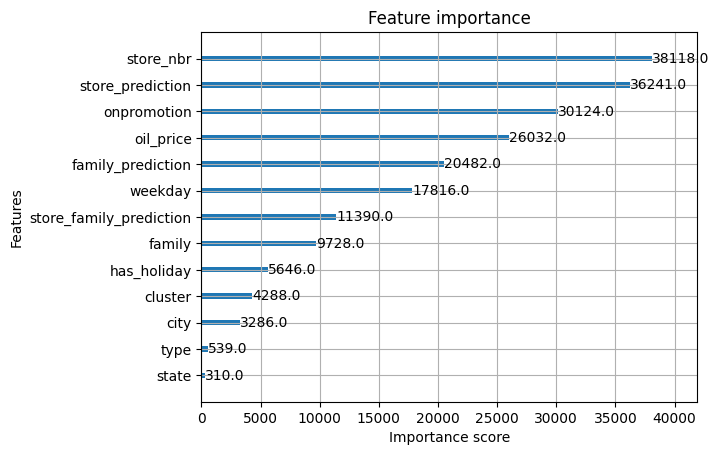

In [190]:
from xgboost import XGBRegressor, plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

Model Inference

In [209]:
test_df = pd.read_csv("data/test.csv")

In [213]:
test_df = process_train_data(test_df, has_holiday_dict, oil_prices_dict, stores_df)

In [210]:
print(len(test_df["date"].unique()))

16


In [ ]:
# We must run a 16 day forecast for dates 2017-08-16 - 2017-08-31
# Train data ends on 2017-08-15
# Inference data must begin at 2017-07-27 inclusive

In [ ]:
def model_inference(test_data):

    category1_dfs_dict, scale_factors1 = process_lstm_data(train_df, grouping_category=1)
    category2_dfs_dict, scale_factors2 = process_lstm_data(train_df, grouping_category=2)
    category3_dfs_dict, scale_factors3 = process_lstm_data(train_df, grouping_category=3)

    
